In [25]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

In [26]:
#Looad preprocessed data
output_dir = Path("processed_outputs")

X_train      = joblib.load(output_dir / "X_train_supervised.pkl")
y_train      = joblib.load(output_dir / "y_train_supervised.pkl")
X_val        = joblib.load(output_dir / "X_val_supervised.pkl")
y_val        = joblib.load(output_dir / "y_val_supervised.pkl")
X_test       = joblib.load(output_dir / "X_test_supervised.pkl")
y_test       = joblib.load(output_dir / "y_test_supervised.pkl")
le           = joblib.load(output_dir / "label_encoder_supervised.pkl")
cw           = joblib.load(output_dir / "class_weights_supervised.pkl")
feature_names = joblib.load(output_dir / "feature_names.pkl")

print("Train shape:", X_train.shape)
print("Classes    :", list(le.classes_))

Train shape: (689284, 37)
Classes    : ['Bot', 'DDoS', 'DoS-GoldenEye', 'DoS-Hulk', 'DoS-SlowHTTPTest', 'DoS-Slowloris', 'FTP-BruteForce', 'PortScan', 'SSH-BruteForce', 'Web-Attack']


c:\Users\Nourhan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.4.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [27]:
#Build sample_weight vector
sample_weight = np.array([cw[label] for label in y_train])

In [28]:
model = XGBClassifier(
    objective        = "multi:softprob",
    num_class        = len(le.classes_),
    n_estimators     = 1000,        
    learning_rate    = 0.05,    
    max_depth        = 7,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 5,
    gamma            = 0.1,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    tree_method      = "hist",
    device           = "cpu",
    eval_metric      = ["mlogloss"],   
    early_stopping_rounds = 50,    
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 1,
)


In [29]:
model.fit(
    X_train, y_train,
    sample_weight = sample_weight,
    eval_set      = [(X_val, y_val)],
    verbose       = 50,
)

print("Best iteration:", model.best_iteration)

[0]	validation_0-mlogloss:2.06656
[50]	validation_0-mlogloss:0.16861
[100]	validation_0-mlogloss:0.05277
[150]	validation_0-mlogloss:0.03924
[200]	validation_0-mlogloss:0.03552
[250]	validation_0-mlogloss:0.03362
[300]	validation_0-mlogloss:0.03263
[350]	validation_0-mlogloss:0.03221
[400]	validation_0-mlogloss:0.03191
[450]	validation_0-mlogloss:0.03174
[500]	validation_0-mlogloss:0.03163
[550]	validation_0-mlogloss:0.03152
[600]	validation_0-mlogloss:0.03147
[650]	validation_0-mlogloss:0.03145
[700]	validation_0-mlogloss:0.03142
[750]	validation_0-mlogloss:0.03143
[800]	validation_0-mlogloss:0.03139
[850]	validation_0-mlogloss:0.03138
[900]	validation_0-mlogloss:0.03139
[926]	validation_0-mlogloss:0.03137
Best iteration: 876


In [30]:
#Evaluate on validation set
y_val_pred = model.predict(X_val)

print("\n── Validation Report ──")
print(classification_report(
    y_val, y_val_pred,
    target_names = le.classes_,
    digits       = 4
))


── Validation Report ──
                  precision    recall  f1-score   support

             Bot     1.0000    1.0000    1.0000     21888
            DDoS     0.9941    0.9735    0.9837     44990
   DoS-GoldenEye     0.8673    0.9650    0.9135      7746
        DoS-Hulk     0.9978    0.9946    0.9962     31889
DoS-SlowHTTPTest     0.9849    0.9874    0.9861       792
   DoS-Slowloris     0.9983    0.9987    0.9985      2293
  FTP-BruteForce     0.9922    0.9933    0.9928       898
        PortScan     0.9998    0.9995    0.9996     13604
  SSH-BruteForce     1.0000    0.9999    0.9999     14579
      Web-Attack     0.7247    0.9842    0.8348       444

        accuracy                         0.9880    139123
       macro avg     0.9559    0.9896    0.9705    139123
    weighted avg     0.9891    0.9880    0.9883    139123



In [31]:
#Evaluate on held-out test set
y_test_pred = model.predict(X_test)

print("\n── Test Report ──")
print(classification_report(
    y_test, y_test_pred,
    target_names = le.classes_,
    digits       = 4
))


── Test Report ──
                  precision    recall  f1-score   support

             Bot     1.0000    1.0000    1.0000     21888
            DDoS     0.9953    0.9738    0.9844     44989
   DoS-GoldenEye     0.8680    0.9730    0.9175      7745
        DoS-Hulk     0.9985    0.9946    0.9966     31890
DoS-SlowHTTPTest     0.9873    0.9823    0.9848       793
   DoS-Slowloris     0.9965    0.9987    0.9976      2294
  FTP-BruteForce     0.9922    0.9911    0.9916       897
        PortScan     0.9999    0.9992    0.9995     13604
  SSH-BruteForce     1.0000    0.9999    1.0000     14580
      Web-Attack     0.7136    0.9842    0.8273       443

        accuracy                         0.9885    139123
       macro avg     0.9551    0.9897    0.9699    139123
    weighted avg     0.9897    0.9885    0.9888    139123



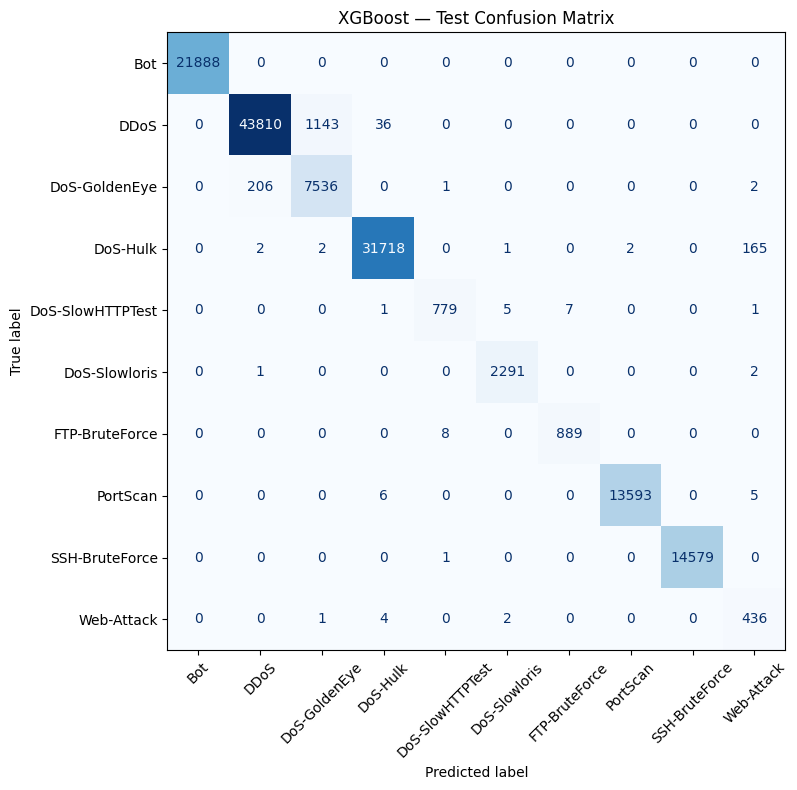

In [32]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False, cmap="Blues")
ax.set_title("XGBoost — Test Confusion Matrix")
plt.tight_layout()
plt.savefig(output_dir / "confusion_matrix_xgb.png", dpi=150)
plt.show()

In [33]:
importance = model.feature_importances_
fi_df = (
    __import__("pandas").DataFrame({"feature": feature_names, "importance": importance})
    .sort_values("importance", ascending=False)
    .head(20)
)

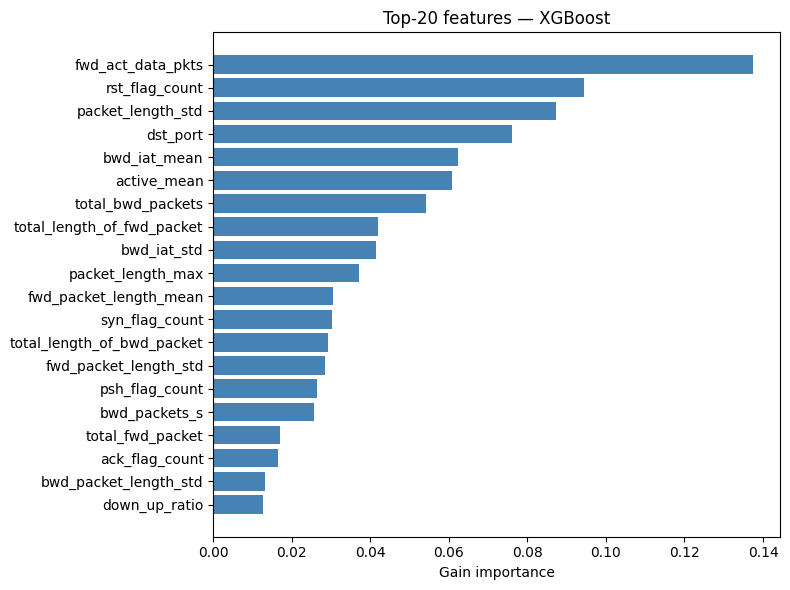

In [34]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(fi_df["feature"][::-1], fi_df["importance"][::-1], color="steelblue")
ax.set_xlabel("Gain importance")
ax.set_title("Top-20 features — XGBoost")
plt.tight_layout()
plt.savefig(output_dir / "feature_importance_xgb.png", dpi=150)
plt.show()

In [35]:
import pandas as pd

y_test_pred = model.predict(X_test)
le = joblib.load(output_dir / "label_encoder_supervised.pkl")

cm = pd.DataFrame(
    confusion_matrix(y_test, y_test_pred),
    index=le.classes_,
    columns=le.classes_
)

# Show only the Web-Attack row and column
print("What Web-Attack gets predicted as:")
print(cm.loc["Web-Attack"])

print("\nWhat gets misclassified AS Web-Attack:")
print(cm["Web-Attack"])

What Web-Attack gets predicted as:
Bot                   0
DDoS                  0
DoS-GoldenEye         1
DoS-Hulk              4
DoS-SlowHTTPTest      0
DoS-Slowloris         2
FTP-BruteForce        0
PortScan              0
SSH-BruteForce        0
Web-Attack          436
Name: Web-Attack, dtype: int64

What gets misclassified AS Web-Attack:
Bot                   0
DDoS                  0
DoS-GoldenEye         2
DoS-Hulk            165
DoS-SlowHTTPTest      1
DoS-Slowloris         2
FTP-BruteForce        0
PortScan              5
SSH-BruteForce        0
Web-Attack          436
Name: Web-Attack, dtype: int64


c:\Users\Nourhan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.4.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [52]:
#Web-Attack Confidence Threshold Tuning
y_proba = model.predict_proba(X_test)
web_attack_idx = list(le.classes_).index("Web-Attack")

for threshold in [0.8, 0.85, 0.88, 0.90, 0.92, 0.95]:
    y_pred_custom = np.argmax(y_proba, axis=1).copy()
    
    for i, probs in enumerate(y_proba):
        sorted_idx = np.argsort(probs)[::-1]
        if sorted_idx[0] == web_attack_idx and probs[web_attack_idx] < threshold:
            y_pred_custom[i] = sorted_idx[1]
    
    report = classification_report(
        y_test, y_pred_custom,
        target_names=le.classes_,
        output_dict=True,
        zero_division=0
    )
    wa = report["Web-Attack"]
    overall_acc = report["accuracy"]
    print(f"threshold={threshold:.2f} | precision={wa['precision']:.3f} | "
          f"recall={wa['recall']:.3f} | f1={wa['f1-score']:.3f} | "
          f"overall_acc={overall_acc:.4f}")

threshold=0.80 | precision=0.797 | recall=0.977 | f1=0.878 | overall_acc=0.9889
threshold=0.85 | precision=0.826 | recall=0.977 | f1=0.896 | overall_acc=0.9890
threshold=0.88 | precision=0.865 | recall=0.968 | f1=0.914 | overall_acc=0.9892
threshold=0.90 | precision=0.877 | recall=0.962 | f1=0.917 | overall_acc=0.9892
threshold=0.92 | precision=0.887 | recall=0.957 | f1=0.921 | overall_acc=0.9892
threshold=0.95 | precision=0.921 | recall=0.946 | f1=0.933 | overall_acc=0.9893


In [58]:
THRESHOLD = 0.95
web_attack_idx = list(le.classes_).index("Web-Attack")

y_proba = model.predict_proba(X_test)
y_pred_final = np.argmax(y_proba, axis=1).copy()

for i, probs in enumerate(y_proba):
    sorted_idx = np.argsort(probs)[::-1]
    if sorted_idx[0] == web_attack_idx and probs[web_attack_idx] < THRESHOLD:
        y_pred_final[i] = sorted_idx[1]

print(classification_report(
    y_test, y_pred_final,
    target_names=le.classes_,
    digits=4
))


                  precision    recall  f1-score   support

             Bot     1.0000    1.0000    1.0000     21888
            DDoS     0.9953    0.9738    0.9844     44989
   DoS-GoldenEye     0.8680    0.9730    0.9175      7745
        DoS-Hulk     0.9981    0.9988    0.9984     31890
DoS-SlowHTTPTest     0.9848    0.9823    0.9836       793
   DoS-Slowloris     0.9952    0.9991    0.9972      2294
  FTP-BruteForce     0.9922    0.9911    0.9916       897
        PortScan     0.9998    0.9993    0.9995     13604
  SSH-BruteForce     1.0000    0.9999    1.0000     14580
      Web-Attack     0.9209    0.9458    0.9332       443

        accuracy                         0.9893    139123
       macro avg     0.9754    0.9863    0.9805    139123
    weighted avg     0.9902    0.9893    0.9895    139123



In [55]:
y_pred_val = model.predict(X_val)
val_proba  = model.predict_proba(X_val)

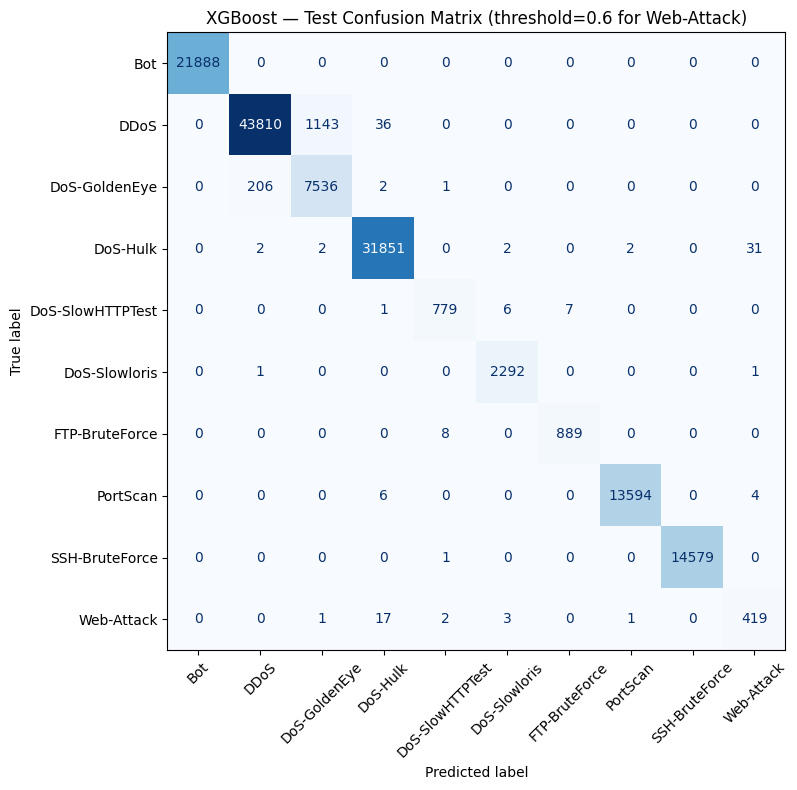

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False, cmap="Blues")
ax.set_title("XGBoost — Test Confusion Matrix (threshold=0.6 for Web-Attack)")
plt.tight_layout()
plt.savefig(output_dir / "confusion_matrix_xgb_final.png", dpi=150)
plt.show()

In [49]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import pandas as pd

y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))

auc_scores = {}
for i, cls in enumerate(le.classes_):
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    auc_scores[cls] = round(auc, 4)

auc_df = pd.DataFrame.from_dict(auc_scores, orient="index", columns=["ROC-AUC"])
print(auc_df.sort_values("ROC-AUC", ascending=False))

                  ROC-AUC
Bot                1.0000
DoS-Hulk           1.0000
SSH-BruteForce     1.0000
DoS-SlowHTTPTest   1.0000
PortScan           1.0000
FTP-BruteForce     1.0000
Web-Attack         0.9999
DDoS               0.9998
DoS-Slowloris      0.9998
DoS-GoldenEye      0.9991


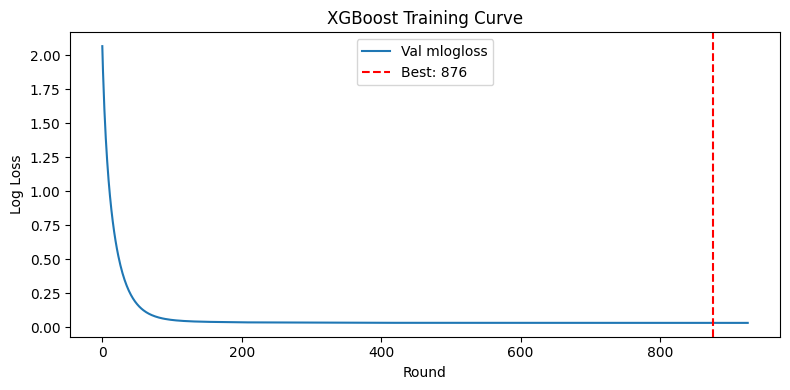

In [50]:
results = model.evals_result()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results["validation_0"]["mlogloss"], label="Val mlogloss")
ax.axvline(model.best_iteration, color="red", linestyle="--", 
           label=f"Best: {model.best_iteration}")
ax.set_xlabel("Round")
ax.set_ylabel("Log Loss")
ax.set_title("XGBoost Training Curve")
ax.legend()
plt.tight_layout()
plt.savefig(output_dir / "training_curve_xgb.png", dpi=150)
plt.show()

In [57]:
import os

project_root = os.path.abspath(os.path.join(os.getcwd()))
models_path  = os.path.join(project_root, "Models")
os.makedirs(models_path, exist_ok=True)

# Predictions
joblib.dump(y_pred_val,   os.path.join(models_path, "xgb_preds_val.pkl"))
joblib.dump(y_pred_final, os.path.join(models_path, "xgb_preds_test.pkl"))

# Model
joblib.dump(model, os.path.join(models_path, "xgb_model.pkl"))
model.save_model(os.path.join(models_path, "xgb_model.json"))

# Probability scores
joblib.dump(val_proba, os.path.join(models_path, "xgb_val_scores.pkl"))
joblib.dump(y_proba,   os.path.join(models_path, "xgb_test_scores.pkl"))

# Threshold
joblib.dump(0.95, os.path.join(models_path, "xgb_web_attack_threshold.pkl"))

print("XGBoost artifacts saved to:", models_path)

XGBoost artifacts saved to: c:\Users\Nourhan\Desktop\AI_Cybersecurity\Models
